In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/gpu_ml_ready.csv")

In [2]:
selected_features = [
    'releaseyear',
    'memsize',
    'unifiedshader',
    'g2dmark',
    'tdp',
    'powerperformance',
    'performance_per_watt',
    'performance_per_gb',
    'performance_per_shader',
    'gpu_age'
]

X = df[selected_features]

y = df["g3dmark"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [7]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(
    X_test_scaled
)

r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("R² Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

R² Score : 0.8775047042830172
MAE      : 962.8842631860048
RMSE     : 1565.9830718647638


In [8]:
results = pd.DataFrame({
    "Model":["Linear Regression"],
    "R2":[r2],
    "MAE":[mae],
    "RMSE":[rmse]
})

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.877505,962.884263,1565.983072


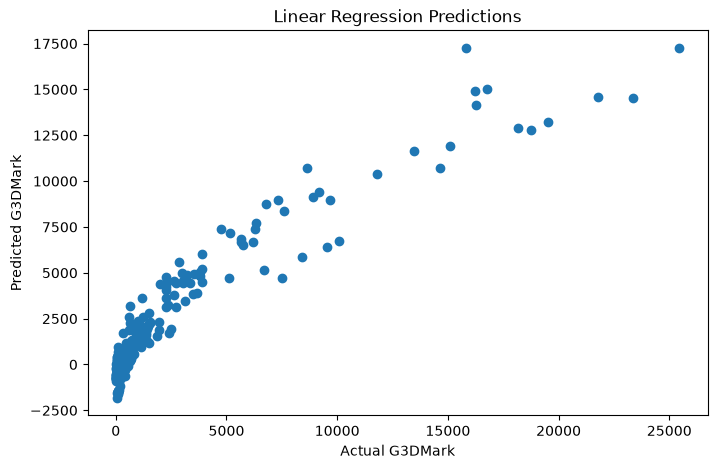

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual G3DMark")
plt.ylabel("Predicted G3DMark")

plt.title("Linear Regression Predictions")

plt.show()

In [10]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_scaled,
    y_train
)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [12]:
y_pred_ridge = ridge.predict(
    X_test_scaled
)


from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2 = r2_score(
    y_test,
    y_pred_ridge
)

mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge
    )
)

print("R2 :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 : 0.8773866572478771
MAE : 963.6039656220886
RMSE : 1566.737448358976


In [13]:
results.loc[len(results)] = [
    "Ridge Regression",
    r2,
    mae,
    rmse
]

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.877505,962.884263,1565.983072
1,Ridge Regression,0.877387,963.603966,1566.737448


In [14]:
from sklearn.linear_model import Lasso

lasso = Lasso(
    alpha=1.0,
    max_iter=10000
)

lasso.fit(
    X_train_scaled,
    y_train
)

,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [16]:
y_pred_lasso = lasso.predict(
    X_test_scaled
)

r2 = r2_score(
    y_test,
    y_pred_lasso
)

mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lasso
    )
)

print("R2 :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 : 0.8774317989966272
MAE : 962.7266361171442
RMSE : 1566.449014092866


In [18]:
lasso_features = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

lasso_features.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
1,memsize,1850.723552
5,powerperformance,1078.060382
3,g2dmark,662.693671
4,tdp,657.128233
7,performance_per_gb,586.310227
2,unifiedshader,353.398092
0,releaseyear,152.706828
8,performance_per_shader,-13.378542
6,performance_per_watt,0.000000
9,gpu_age,-0.000000


In [17]:
results.loc[len(results)] = [
    "Lasso Regression",
    r2,
    mae,
    rmse
]

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.877505,962.884263,1565.983072
1,Ridge Regression,0.877387,963.603966,1566.737448
2,Lasso Regression,0.877432,962.726636,1566.449014


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [21]:
y_pred_rf = rf.predict(
    X_test
)


r2 = r2_score(
    y_test,
    y_pred_rf
)

mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("R2 :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 : 0.9834686911624432
MAE : 201.17315450643778
RMSE : 575.2822542672296


In [22]:
results.loc[len(results)] = [
    "Random Forest",
    r2,
    mae,
    rmse
]

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.877505,962.884263,1565.983072
1,Ridge Regression,0.877387,963.603966,1566.737448
2,Lasso Regression,0.877432,962.726636,1566.449014
3,Random Forest,0.983469,201.173155,575.282254


In [23]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,memsize,0.488172
3,g2dmark,0.322440
7,performance_per_gb,0.081497
4,tdp,0.046210
8,performance_per_shader,0.015085
5,powerperformance,0.014532
6,performance_per_watt,0.013501
2,unifiedshader,0.007221
0,releaseyear,0.006032
9,gpu_age,0.005311
